# 02. V1 도구 개발 (Tools V1)

> Part 02에서 `@tool`, `bind_tools`, `ToolNode`로 도구 루프의 기본을 배웠다면, 여기서는 V1 도구가 **런타임 정보에 접근하고 상태를 업데이트하는 방법**을 배웁니다.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. Part 02의 `@tool` 기초를 V1 에이전트 도구 정의에 적용할 수 있어요
2. Pydantic `args_schema`로 타입 검증과 입력 제한을 구현할 수 있어요
3. `ToolRuntime`을 통해 에이전트 상태, 컨텍스트, 메모리 스토어에 접근할 수 있어요
4. `Command`와 `RemoveMessage`로 도구 내에서 상태를 동적으로 업데이트할 수 있어요
5. `runtime.stream_writer`로 도구 실행 진행 상황을 실시간 스트리밍할 수 있어요

## 사전 지식

- `02_LangGraph_Basics/06-Tools-Integration.ipynb`: `@tool`, `bind_tools`, `ToolNode`, `tools_condition`
- `01-Create-Agent.ipynb`: `create_agent`, `AgentState`, 에이전트 루프
- Pydantic BaseModel 기본 사용법


## V1 도구에서 새로 보는 것

도구가 “LLM이 호출할 수 있는 함수”라는 기본 개념은 `02_LangGraph_Basics/06-Tools-Integration.ipynb`에서 이미 배웠어요. 이 노트북의 초점은 기본 도구 루프가 아니라, V1 도구가 실행 중에 접근할 수 있는 **런타임 표면**입니다.

```
도구 = 함수 + 이름 + 설명 + 입력 스키마
V1 도구 확장 = ToolRuntime + Command + stream_writer + store/context 접근
```

### V1 도구의 주요 구성 요소

| 구성 요소 | Part 02와의 관계 | 이 노트북의 초점 |
|----------|------------------|------------------|
| `@tool` 데코레이터 | 기본 사용법 복습 | 이름/설명/스키마 품질 점검 |
| `args_schema` | Part 02보다 상세 | Pydantic 검증과 `Literal` 제한 |
| `ToolRuntime` | 새 초점 | state, context, store, stream_writer 접근 |
| `Command` 반환 | 새 초점 | 도구 실행 중 상태 업데이트 |
| `stream_writer` | 새 초점 | 장시간 도구 진행 상황 전송 |

> 🔑 **핵심 개념**: LLM은 여전히 도구의 이름·설명·스키마를 보고 호출을 결정해요. 하지만 V1 도구는 `ToolRuntime`을 통해 LLM에게 노출하지 않는 실행 컨텍스트까지 사용할 수 있습니다.


## 환경 설정

In [1]:
# 환경 변수 로드 (.env 파일에서 OPENAI_API_KEY 등을 읽어와요)
from dotenv import load_dotenv
load_dotenv()

# LangSmith 추적 설정 (선택 사항)
import os
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-V1-Tools"

## 1. @tool 데코레이터로 기본 도구 만들기

`@tool`의 기본 동작은 Part 02에서 다뤘으므로 여기서는 빠르게 복습합니다. Python 함수에 데코레이터를 붙이면 이름, docstring, 타입 힌트가 도구 스키마로 추출돼요.

**자동 추출 항목:**
- **이름**: 함수 이름 (`search_database` → `search_database`)
- **설명**: 함수의 docstring
- **입력 스키마**: 타입 힌트에서 자동 생성

> 🎯 **강의 포인트**: 이 섹션은 이후 `args_schema`, `ToolRuntime`, `Command`를 이해하기 위한 짧은 베이스라인입니다. 도구 루프 전체 구조는 `02_LangGraph_Basics/06-Tools-Integration.ipynb`를 참조하세요.


In [2]:
# LangChain V1 도구 임포트
from langchain.tools import tool


# @tool 데코레이터로 기본 도구를 정의해요
@tool
def search_database(query: str, limit: int = 10) -> str:
    """Search the customer database for records matching the query.

    Args:
        query: Search terms to look for
        limit: Maximum number of results to return
    """
    # 실제로는 DB 쿼리를 수행하지만, 여기서는 시뮬레이션해요
    return f"Found {limit} results for '{query}'"


# 도구의 메타데이터를 확인해봐요
print(f"도구 이름: {search_database.name}")
print(f"도구 설명: {search_database.description}")
print(f"입력 스키마: {search_database.args}")

도구 이름: search_database
도구 설명: Search the customer database for records matching the query.

Args:
    query: Search terms to look for
    limit: Maximum number of results to return
입력 스키마: {'query': {'title': 'Query', 'type': 'string'}, 'limit': {'default': 10, 'title': 'Limit', 'type': 'integer'}}


### 1-1. 커스텀 이름과 설명 설정

함수 이름 대신 더 설명적인 도구 이름을 쓰고 싶을 때, 또는 docstring과 별도로 모델에게 다른 설명을 전달하고 싶을 때 사용해요.

> 💡 **실무 팁**: 도구 이름은 `snake_case`로 작성하고, 동사로 시작하는 것이 좋아요 (`search_`, `get_`, `create_`, `update_`). 모델이 도구의 목적을 이름만으로도 유추할 수 있어요.

In [3]:
# 커스텀 이름 지정: @tool("원하는_이름")
@tool("web_search")  # 함수 이름(search)과 다른 도구 이름
def search(query: str) -> str:
    """Search the web for information."""
    return f"Results for: {query}"


# description 파라미터로 모델에게 전달할 설명을 별도 지정해요
@tool(
    "calculator",
    description="Performs arithmetic calculations. Use this for any math problems including addition, subtraction, multiplication and division.",
)
def calc(expression: str) -> str:
    """Evaluate mathematical expressions."""
    try:
        # 실제 사용 시 안전한 파서를 사용하세요
        return str(eval(expression))
    except Exception as e:
        return f"계산 오류: {e}"


print(f"web_search 이름: {search.name}")         # web_search
print(f"calculator 설명: {calc.description}")    # 커스텀 설명

web_search 이름: web_search
calculator 설명: Performs arithmetic calculations. Use this for any math problems including addition, subtraction, multiplication and division.


## 2. Pydantic으로 입력 스키마 정의하기

파라미터가 복잡하거나 입력값에 제한이 필요할 때는 Pydantic 모델로 `args_schema`를 명시해요.

**Pydantic 스키마의 장점:**
- `Literal["celsius", "fahrenheit"]` 같은 허용값 제한
- `Field(description=...)` 으로 파라미터별 상세 설명
- 자동 타입 검증 및 변환

> 🔑 **핵심 개념**: `Field(description=...)` 에 작성한 내용이 모델에게 전달돼요. "어떤 값을 넣어야 하는지" 모델이 더 잘 이해할 수 있도록 구체적으로 작성하세요.

In [4]:
# Pydantic 임포트
from pydantic import BaseModel, Field
from typing import Literal


# 날씨 조회 도구의 입력 스키마를 Pydantic으로 정의해요
class WeatherInput(BaseModel):
    """날씨 조회 도구의 입력 스키마예요."""

    # 위치: 도시명 또는 좌표
    location: str = Field(description="City name (e.g., Seoul, Tokyo) or coordinates")

    # 온도 단위: celsius 또는 fahrenheit만 허용
    units: Literal["celsius", "fahrenheit"] = Field(
        default="celsius",
        description="Temperature unit: 'celsius' or 'fahrenheit'"
    )

    # 5일 예보 포함 여부
    include_forecast: bool = Field(
        default=False,
        description="Set True to include 5-day weather forecast"
    )


# args_schema 파라미터로 Pydantic 모델을 연결해요
@tool(args_schema=WeatherInput)
def get_weather(
    location: str,
    units: str = "celsius",
    include_forecast: bool = False
) -> str:
    """Get current weather and optional 5-day forecast for a location."""
    # 온도 단위에 따른 기본 온도 시뮬레이션
    temp = 22 if units == "celsius" else 72
    unit_label = "°C" if units == "celsius" else "°F"
    result = f"{location} 현재 온도: {temp}{unit_label}"

    if include_forecast:
        result += "\n5일 예보: 맑음 > 구름 > 비 > 맑음 > 맑음"
    return result


# 정상 입력 테스트
# === 정상 입력 ===
print(get_weather.invoke({"location": "Seoul", "units": "celsius", "include_forecast": True}))

Seoul 현재 온도: 22°C
5일 예보: 맑음 > 구름 > 비 > 맑음 > 맑음


In [5]:
# Literal 타입 위반 시 Pydantic이 자동으로 검증 오류를 발생시켜요
try:
    result = get_weather.invoke({"location": "Seoul", "units": "kelvin"})  # 허용되지 않는 값
except Exception as e:
    print(f"검증 오류 발생: {type(e).__name__}")
    # units는 'celsius' 또는 'fahrenheit'만 허용돼요

검증 오류 발생: ValidationError


> 🎯 **강의 포인트**: `Literal` 타입은 단순한 검증 이상의 역할을 해요. 모델이 스키마를 읽을 때 허용값 목록을 보고 "celsius 아니면 fahrenheit"라고 학습하기 때문에, 잘못된 값을 입력할 가능성이 처음부터 줄어들어요.

## 3. ToolRuntime - 런타임 정보 접근

`ToolRuntime`은 도구가 실행될 때 주입되는 특별한 매개변수예요. 에이전트의 상태, 사용자 컨텍스트, 장기 메모리 스토어 등에 접근할 수 있어요.

**중요한 특성:**
- `runtime: ToolRuntime`을 도구 시그니처에 추가하면 모델에게는 **보이지 않아요**
- 실행 시 LangGraph 프레임워크가 자동으로 주입해요
- 단일 객체로 여러 컨텍스트 소스에 접근 가능

```mermaid
flowchart LR
    TR[ToolRuntime] --> S[.state<br/>현재 그래프 상태]
    TR --> C[.context<br/>불변 사용자 컨텍스트]
    TR --> ST[.store<br/>영구 장기 메모리]
    TR --> SW[.stream_writer<br/>실시간 스트리밍]
    TR --> ID[.tool_call_id<br/>현재 도구 호출 ID]

    classDef runtime fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef prop fill:#cce5ff,stroke:#007bff,color:#004085
    class TR runtime
    class S,C,ST,SW,ID prop
```

### ToolRuntime 속성별 용도 비교

| 속성 | 데이터 성격 | 지속성 | 대표 사용 사례 |
|------|-----------|--------|-------------|
| `.state` | 대화 중 변하는 동적 데이터 | 세션 내 | 메시지 이력, 카운터 |
| `.context` | 요청 시 주입되는 불변 데이터 | 단일 호출 | user_id, 권한, 설정 |
| `.store` | 세션을 넘어 영속하는 데이터 | 영구 | 사용자 선호도, 검색 기록 |
| `.stream_writer` | 실시간 이벤트 전송 | 즉시 | 진행률, 중간 결과 |
| `.tool_call_id` | 현재 호출 식별자 | 단일 호출 | Command 반환 시 필수 |

> 💡 **실무 팁**: `runtime.state`는 읽기 전용으로 사용하고, 상태를 바꿔야 할 때는 `Command`를 반환하세요. 직접 state를 변경하면 예측 불가능한 동작이 생길 수 있어요.

### 3-1. runtime.state - 현재 대화 상태 접근

In [6]:
# ToolRuntime 임포트
from langchain.tools import tool, ToolRuntime
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model


# runtime.state로 현재 대화 히스토리에 접근해요
@tool
def summarize_conversation(runtime: ToolRuntime) -> str:
    """현재 대화의 메시지 통계를 반환해요."""
    messages = runtime.state.get("messages", [])

    # 메시지 타입별 카운트
    human_count = sum(1 for m in messages if m.__class__.__name__ == "HumanMessage")
    ai_count = sum(1 for m in messages if m.__class__.__name__ == "AIMessage")
    tool_count = sum(1 for m in messages if m.__class__.__name__ == "ToolMessage")

    return (
        f"대화 통계 - "
        f"사용자: {human_count}개, "
        f"AI 응답: {ai_count}개, "
        f"도구 결과: {tool_count}개"
    )


# gpt-4o-mini 모델로 에이전트 생성
model = init_chat_model("openai:gpt-4o-mini")
agent = create_agent(
    model,
    tools=[summarize_conversation],
    system_prompt="You are a helpful assistant. Respond in Korean.",
)

# 에이전트 실행
result = agent.invoke(
    {"messages": [{"role": "user", "content": "지금까지 대화 통계를 알려줘"}]}
)
print(result["messages"][-1].content)

대화 통계는 다음과 같습니다:
- 사용자 메시지: 1개
- AI 응답: 1개
- 도구 결과: 0개


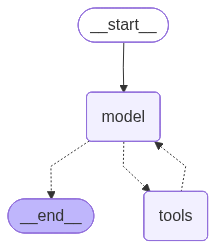

In [7]:
# 그래프 흐름: START → model → {tools_condition} → tools 또는 END
# model 노드: LLM이 메시지를 처리하고 도구 호출 여부를 결정해요
# tools 노드: summarize_conversation 도구를 실행해요
# 도구 실행 후 다시 model로 돌아가 최종 응답을 생성해요
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

### 3-2. runtime.context - 사용자 컨텍스트 활용

In [8]:
# 컨텍스트 스키마와 관련 임포트
from dataclasses import dataclass
from langchain.tools import tool, ToolRuntime
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model

# 사용자 데이터베이스 시뮬레이션
USER_DATABASE = {
    "user123": {
        "name": "김철수",
        "account_type": "Premium",
        "balance": 5_000_000,
        "email": "chulsoo@example.com",
    },
    "user456": {
        "name": "이영희",
        "account_type": "Standard",
        "balance": 1_200_000,
        "email": "younghee@example.com",
    },
}


# 컨텍스트 스키마 정의: user_id를 에이전트 실행 시 주입해요
@dataclass
class UserContext:
    user_id: str  # 에이전트 호출 시 전달되는 사용자 ID


# ToolRuntime[UserContext]로 타입 힌트를 명시하면 더 명확해요
@tool
def get_account_info(runtime: ToolRuntime) -> str:
    """현재 로그인한 사용자의 계좌 정보를 조회해요."""
    # runtime.context에서 user_id를 꺼내요
    user_id = runtime.context.user_id

    if user_id in USER_DATABASE:
        user = USER_DATABASE[user_id]
        return (
            f"계좌 소유자: {user['name']}\n"
            f"계좌 유형: {user['account_type']}\n"
            f"잔액: {user['balance']:,}원"
        )
    return "사용자를 찾을 수 없어요"


# context_schema 파라미터로 컨텍스트 스키마를 에이전트에 등록해요
model = init_chat_model("openai:gpt-4o-mini")
agent = create_agent(
    model,
    tools=[get_account_info],
    context_schema=UserContext,  # 클래스 자체를 전달 (인스턴스가 아님)
    system_prompt="You are a banking assistant. Respond in Korean.",
)

# context= 파라미터로 사용자 정보를 실행 시 주입해요
result = agent.invoke(
    {"messages": [{"role": "user", "content": "내 계좌 잔액이 얼마야?"}]},
    context=UserContext(user_id="user123"),  # 실행마다 다른 사용자 ID 전달 가능
)
print(result["messages"][-1].content)

/Users/mhso/working/lecture/llm/langchain-llm/03_langgraph-agents/.venv/lib/python3.14/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='context', input_value=UserContext(user_id='user123'), input_type=UserContext])
  return self.__pydantic_serializer__.to_python(


계좌 소유자 김철수님의 계좌 잔액은 5,000,000원입니다.


> 🎯 **강의 포인트**: `context`는 매 요청마다 달라지는 정보를 전달할 때 써요. 예를 들어 웹 앱에서 로그인한 사용자의 ID나 권한 레벨을 context로 넘기면, 도구가 요청자에 맞는 데이터만 반환할 수 있어요.

> 🔑 **핵심 개념**: `state`는 대화 중 바뀌는 동적 데이터 (`messages`, 카운터 등)이고, `context`는 요청이 들어올 때 한 번 설정되는 불변 데이터 (`user_id`, 세션 설정 등)예요.

### 3-3. runtime.store - 장기 메모리 스토어

In [9]:
# InMemoryStore와 관련 임포트
from typing import Any
from langgraph.store.memory import InMemoryStore
from langchain.tools import tool, ToolRuntime
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model


# Store에서 데이터를 읽는 도구
@tool
def get_user_info(user_id: str, runtime: ToolRuntime) -> str:
    """저장된 사용자 정보를 조회해요."""
    # ("users",) 네임스페이스에서 user_id 키로 조회
    item = runtime.store.get(("users",), user_id)
    return str(item.value) if item else f"'{user_id}' 사용자 정보 없음"


# Store에 데이터를 저장하는 도구
@tool
def save_user_info(
    user_id: str,
    user_info: dict[str, Any],
    runtime: ToolRuntime
) -> str:
    """사용자 정보를 장기 메모리에 저장해요."""
    # 네임스페이스=("users",), 키=user_id, 값=user_info
    runtime.store.put(("users",), user_id, user_info)
    return f"'{user_id}' 사용자 정보가 저장됐어요"


# InMemoryStore 인스턴스를 만들어 에이전트에 연결해요
store = InMemoryStore()
model = init_chat_model("openai:gpt-4o-mini")
agent = create_agent(
    model,
    tools=[get_user_info, save_user_info],
    store=store,  # store= 파라미터로 영구 메모리 연결
    system_prompt="You are a helpful assistant. Respond in Korean.",
)

# 첫 번째 대화: 사용자 정보 저장
# === 사용자 정보 저장 ===
result1 = agent.invoke({
    "messages": [{
        "role": "user",
        "content": "사용자 정보 저장해줘: user_id=u001, 이름=박민준, 나이=30, 직업=개발자"
    }]
})
print(result1["messages"][-1].content)

# 두 번째 대화 (새 세션): 이전에 저장한 정보 조회
# === 저장된 정보 조회 ===
result2 = agent.invoke({
    "messages": [{
        "role": "user",
        "content": "u001 사용자 정보 알려줘"
    }]
})
print(result2["messages"][-1].content)

사용자 정보가 성공적으로 저장되었습니다: 사용자 ID는 u001, 이름은 박민준, 나이는 30세, 직업은 개발자입니다.
u001 사용자의 정보는 다음과 같습니다:

- 이름: 박민준
- 나이: 30세
- 직업: 개발자


> 💡 **실무 팁**: `InMemoryStore`는 프로세스가 종료되면 데이터가 사라져요. 프로덕션에서는 `PostgresStore` 또는 `RedisStore`를 사용해서 영구 저장하세요. Part 7에서 장기 메모리를 더 자세히 다뤄요.

## 4. Command로 도구 내에서 상태 업데이트하기

일반 도구는 문자열을 반환해서 `ToolMessage`로 변환되지만, `Command`를 반환하면 **도구 실행 중에 에이전트 상태를 직접 업데이트**할 수 있어요.

```python
return Command(
    update={
        "user_name": new_name,      # 커스텀 상태 필드 업데이트
        "messages": [ToolMessage(   # 메시지 히스토리에 추가
            content="완료",
            tool_call_id=runtime.tool_call_id,  # 필수!
        )]
    }
)
```

> ⚠️ **자주 하는 실수**: `Command`로 상태를 업데이트할 때 `messages`에 반드시 `ToolMessage`를 포함해야 해요. `tool_call_id`도 `runtime.tool_call_id`에서 정확히 가져와야 에이전트가 어떤 도구 호출에 대한 응답인지 추적할 수 있어요.

In [10]:
# Command와 관련 임포트
from typing_extensions import TypedDict
from langgraph.types import Command
from langchain.tools import tool, ToolRuntime
from langchain.agents import create_agent, AgentState
from langchain.chat_models import init_chat_model
from langchain.messages import ToolMessage
from langgraph.checkpoint.memory import InMemorySaver


# 커스텀 상태 스키마: AgentState(TypedDict)를 확장해요
# 공식 문서 권장: "Custom state schemas must extend AgentState as a TypedDict."
# https://docs.langchain.com/oss/python/langchain/tools.md
class CustomState(AgentState):
    user_name: str  # 추가 커스텀 필드


# 사용자 이름을 상태에 저장하는 도구
# ToolRuntime[None, CustomState]로 state 타입을 명시하면 runtime.state["user_name"] 자동완성도 잘 돼요
@tool
def update_user_name(new_name: str, runtime: ToolRuntime) -> Command:
    """Update the user's name in the conversation state."""
    # Command.update로 상태를 업데이트해요
    return Command(
        update={
            "user_name": new_name,  # CustomState의 user_name 필드 업데이트
            "messages": [
                ToolMessage(
                    content=f"이름을 '{new_name}'(으)로 저장했어요",
                    # tool_call_id는 반드시 runtime에서 가져와야 해요
                    tool_call_id=runtime.tool_call_id,
                )
            ],
        }
    )


# 체크포인터가 있어야 대화 히스토리를 유지해요
model = init_chat_model("openai:gpt-4o-mini")
agent = create_agent(
    model,
    tools=[update_user_name],
    system_prompt="You are a helpful assistant. Respond in Korean.",
    state_schema=CustomState,   # AgentState를 확장한 TypedDict 전달
    checkpointer=InMemorySaver(),
)

# 첫 번째 메시지: 이름 설정
config = {"configurable": {"thread_id": "session-001"}}
result1 = agent.invoke(
    {"messages": [{"role": "user", "content": "내 이름은 민준이야"}]},
    config=config,
)
# === 이름 설정 ===
print(result1["messages"][-1].content)

# 상태에서 user_name이 업데이트됐는지 확인해요
state = agent.get_state(config).values
print(f"\n현재 저장된 이름: '{state.get('user_name', '없음')}'")

안녕하세요, 민준님! 만나서 반갑습니다. 무엇을 도와드릴까요?

현재 저장된 이름: '민준'


In [11]:
# 이름 변경 테스트
result2 = agent.invoke(
    {"messages": [{"role": "user", "content": "아 사실 내 이름은 지수야"}]},
    config=config,
)
# === 이름 변경 ===
print(result2["messages"][-1].content)

# 상태 다시 확인
state = agent.get_state(config).values
print(f"\n업데이트된 이름: '{state.get('user_name', '없음')}'")

이제 이름이 지수님으로 변경되었습니다! 지수님, 무엇을 도와드릴까요?

업데이트된 이름: '지수'


### 4-1. RemoveMessage로 메시지 히스토리 관리

`RemoveMessage`를 사용하면 대화 히스토리에서 특정 메시지를 삭제할 수 있어요. `Command`와 함께 사용해서 도구 내에서 히스토리를 정리할 수 있어요.

> 🔑 **핵심 개념**: 삭제할 메시지를 `RemoveMessage(id=msg.id)`로 지정해요. 단, 현재 도구 호출과 연결된 `AIMessage`(tool_calls 포함)는 삭제하면 안 돼요 - 삭제하면 응답 쌍이 깨져요.

In [12]:
# RemoveMessage 임포트
from langchain.messages import AIMessage, RemoveMessage
from langgraph.types import Command
from langchain.tools import tool, ToolRuntime


@tool
def clear_messages(runtime: ToolRuntime) -> Command:
    """Clear all conversation messages except the current tool call."""
    messages = runtime.state.get("messages", [])
    tool_call_id = runtime.tool_call_id

    # 현재 도구 호출과 연관된 AIMessage를 제외한 모든 메시지 삭제
    to_remove = []
    for m in messages:
        if isinstance(m, AIMessage) and getattr(m, "tool_calls", None):
            # 현재 tool_call_id와 매칭되는 AIMessage는 유지
            if not any(call.get("id") == tool_call_id for call in m.tool_calls):
                to_remove.append(m)
        else:
            to_remove.append(m)

    # RemoveMessage 리스트 생성
    removals = [RemoveMessage(id=m.id) for m in to_remove]

    return Command(
        update={
            "messages": removals + [
                ToolMessage(
                    content=f"{len(removals)}개 메시지를 삭제했어요",
                    tool_call_id=tool_call_id,
                )
            ]
        }
    )


# 여러 도구를 함께 사용하는 에이전트
model = init_chat_model("openai:gpt-4o-mini")
agent_with_clear = create_agent(
    model,
    tools=[update_user_name, clear_messages],
    system_prompt="You are a helpful assistant. Respond in Korean.",
    state_schema=CustomState,
    checkpointer=InMemorySaver(),
)

config2 = {"configurable": {"thread_id": "session-002"}}

# 대화 쌓기
agent_with_clear.invoke(
    {"messages": [{"role": "user", "content": "내 이름은 하늘이야"}]},
    config=config2,
)
agent_with_clear.invoke(
    {"messages": [{"role": "user", "content": "안녕! 오늘 날씨 어때?"}]},
    config=config2,
)

before_count = len(agent_with_clear.get_state(config2).values["messages"])
print(f"삭제 전 메시지 수: {before_count}개")

# 메시지 삭제
result = agent_with_clear.invoke(
    {"messages": [{"role": "user", "content": "대화 기록 전부 지워줘"}]},
    config=config2,
)
print(result["messages"][-1].content)

after_count = len(agent_with_clear.get_state(config2).values["messages"])
print(f"삭제 후 메시지 수: {after_count}개")

삭제 전 메시지 수: 6개
대화가 깨끗하게 정리되었습니다! 무엇을 도와드릴까요?
삭제 후 메시지 수: 3개


## 5. runtime.stream_writer로 진행 상황 스트리밍

시간이 오래 걸리는 작업을 수행할 때 사용자에게 진행 상황을 실시간으로 알려줄 수 있어요. `runtime.stream_writer`를 호출하면 해당 내용이 즉시 스트림으로 전송돼요.

> 💡 **실무 팁**: `stream_mode="custom"` 으로 그래프를 실행해야 `stream_writer`로 보낸 메시지를 받을 수 있어요. 일반 `stream_mode="updates"` 에서는 커스텀 스트림이 전달되지 않아요.

In [13]:
# stream_writer 사용 예시
import time
from langchain.tools import tool, ToolRuntime
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model


@tool
def analyze_data(data_size: int, runtime: ToolRuntime) -> str:
    """Analyze a dataset and return summary statistics."""
    writer = runtime.stream_writer  # 스트림 라이터 가져오기

    # 단계별 진행 상황을 실시간으로 전송해요
    writer({"step": 1, "message": f"데이터 {data_size}건 로딩 중..."})
    time.sleep(0.1)  # 실제 처리 시뮬레이션

    writer({"step": 2, "message": "데이터 정제 중..."})
    time.sleep(0.1)

    writer({"step": 3, "message": "통계 계산 중..."})
    time.sleep(0.1)

    writer({"step": 4, "message": "분석 완료!"})

    return f"분석 결과: {data_size}건 데이터, 평균 42.5, 표준편차 8.3"


model = init_chat_model("openai:gpt-4o-mini")
agent = create_agent(
    model,
    tools=[analyze_data],
    system_prompt="You are a data analysis assistant. Respond in Korean.",
)

inputs = {"messages": [{"role": "user", "content": "1000건 데이터를 분석해줘"}]}

# stream_mode="custom"으로 stream_writer의 메시지를 받아요
# === 실시간 진행 상황 ===
for chunk in agent.stream(inputs, stream_mode="custom"):
    print(f"[진행] {chunk}")

[진행] {'step': 1, 'message': '데이터 1000건 로딩 중...'}
[진행] {'step': 2, 'message': '데이터 정제 중...'}
[진행] {'step': 3, 'message': '통계 계산 중...'}
[진행] {'step': 4, 'message': '분석 완료!'}


> 🎯 **강의 포인트**: `stream_writer`는 UI 구현 시 핵심이에요. 웹 애플리케이션에서 진행 상황 바를 업데이트하거나, 단계별 로그를 사용자에게 보여줄 때 활용해요. 단계가 많고 시간이 오래 걸리는 RAG 파이프라인, 웹 스크래핑 등에서 특히 유용해요.

## 6. 종합 예제 - 개인화된 추천 에이전트

지금까지 배운 모든 내용을 합쳐서 실제 프로덕션에 가까운 에이전트를 만들어봐요.

- `@tool` + `args_schema`: 입력 검증이 있는 도구
- `runtime.context`: 사용자 ID 기반 개인화
- `runtime.store`: 사용자 선호도 영구 저장
- `Command`: 상태 업데이트

In [ ]:
# 종합 예제 임포트
from typing import Annotated, List, Literal
from dataclasses import dataclass
from pydantic import BaseModel, Field
from langgraph.store.memory import InMemoryStore
from langgraph.types import Command
from langchain.tools import tool, ToolRuntime
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain.messages import AnyMessage, ToolMessage
from langgraph.graph.message import add_messages


# 사용자 컨텍스트: 로그인 시 주입
@dataclass
class AppContext:
    user_id: str
    tier: str = "standard"  # standard 또는 premium


# 도구 1: 사용자 선호도 저장
class SavePreferenceInput(BaseModel):
    category: Literal["music", "food", "movie"] = Field(
        description="Category of preference to save"
    )
    preference: str = Field(description="The user's preference value")


@tool(args_schema=SavePreferenceInput)
def save_preference(
    category: str,
    preference: str,
    runtime: ToolRuntime
) -> Command:
    """Save a user's preference to long-term memory."""
    user_id = runtime.context.user_id

    # 현재 저장된 선호도 로드
    existing = runtime.store.get(("preferences", user_id), "data")
    prefs = existing.value if existing else {}

    # 새 선호도 추가
    prefs[category] = preference
    runtime.store.put(("preferences", user_id), "data", prefs)

    return Command(
        update={
            "messages": [
                ToolMessage(
                    content=f"{category} 선호도 '{preference}'를 저장했어요",
                    tool_call_id=runtime.tool_call_id,
                )
            ]
        }
    )


# 도구 2: 개인화된 추천
@tool
def get_recommendation(
    category: Literal["music", "food", "movie"],
    runtime: ToolRuntime
) -> str:
    """Get personalized recommendation based on stored preferences."""
    user_id = runtime.context.user_id
    tier = runtime.context.tier

    # Store에서 선호도 로드
    existing = runtime.store.get(("preferences", user_id), "data")
    prefs = existing.value if existing else {}

    pref_value = prefs.get(category, None)

    # tier에 따른 추천 품질 차별화
    tier_label = "프리미엄" if tier == "premium" else "일반"

    if pref_value:
        return f"[{tier_label}] '{pref_value}'를 좋아하시는 {user_id}님을 위한 {category} 추천: (개인화 추천 결과)"
    else:
        return f"[{tier_label}] {category} 선호도가 없어요. 먼저 선호도를 저장해주세요!"


# 에이전트 구성
recommendation_store = InMemoryStore()
model = init_chat_model("openai:gpt-4o-mini")
recommendation_agent = create_agent(
    model,
    tools=[save_preference, get_recommendation],
    store=recommendation_store,
    context_schema=AppContext,
    # ⚠️ 핵심: 도구가 있어도 "언제 써야 하는지"를 지시하지 않으면 gpt-4o-mini는
    #   (1) "나는 재즈를 좋아해" 같은 진술을 잡담으로 받고 save_preference를 건너뛰고,
    #   (2) "음악 추천해줘"에는 카테고리 매핑이 없어 장르를 되묻거나,
    #   (3) R2처럼 매 호출이 독립 세션이라 "저장된 게 없으니 먼저 알려달라"며 회피해요.
    # 아래처럼 (a) 도구 사용 시점, (b) 카테고리 매핑, (c) "이전 세션에 이미 저장됐을 수
    # 있으니 먼저 get_recommendation부터 호출하라"를 못박아야 안정적으로 동작합니다.
    system_prompt=(
        "You are a personalized recommendation assistant. Respond in Korean.\n"
        "When the user states a preference, you MUST call save_preference to store it.\n"
        "When the user asks for a recommendation, you MUST call get_recommendation with the "
        "matching category as your FIRST action. The user's preference may already be saved "
        "from a previous session, so NEVER ask the user to provide or save a preference first, "
        "and NEVER ask which genre/kind they want. Only if the tool reports none is saved, ask.\n"
        "Category mapping: 음악->music, 음식->food, 영화->movie."
    ),
)

# Premium 사용자 테스트
premium_ctx = AppContext(user_id="user_premium_01", tier="premium")

# === 선호도 저장 ===
r1 = recommendation_agent.invoke(
    {"messages": [{"role": "user", "content": "나는 재즈 음악을 좋아해"}]},
    context=premium_ctx,
)
print(r1["messages"][-1].content)

# === 개인화 추천 ===
r2 = recommendation_agent.invoke(
    {"messages": [{"role": "user", "content": "음악 추천해줘"}]},
    context=premium_ctx,
)
print(r2["messages"][-1].content)

# === (선택) Store에 실제로 저장됐는지 직접 확인 ===
saved = recommendation_store.get(("preferences", "user_premium_01"), "data")
print("저장된 선호도:", saved.value if saved else "없음")

## 실습 (실습 해설)

지금까지 배운 내용으로 나만의 도구를 만들어봐요!

In [15]:
# ============================================================
# 실습 해설: 날씨 + 옷차림 추천 에이전트 만들기
# ============================================================

from typing import Literal
from dataclasses import dataclass
from pydantic import BaseModel, Field
from langgraph.store.memory import InMemoryStore
from langchain.tools import tool, ToolRuntime
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model


@dataclass
class WeatherContext:
    user_id: str = "default_user"


@tool
def get_temperature(city: str, runtime: ToolRuntime[WeatherContext]) -> str:
    """도시별 기온을 Store에서 조회하고, 없으면 기본 기온을 저장해요."""
    namespace = ("weather", runtime.context.user_id)
    key = city.lower()
    saved = runtime.store.get(namespace, key)

    if saved is None:
        default_temperatures = {"서울": 18.0, "부산": 22.0, "제주": 24.0}
        temperature = default_temperatures.get(city, 20.0)
        runtime.store.put(namespace, key, {"city": city, "temperature": temperature})
    else:
        temperature = saved.value["temperature"]

    return f"{city}의 현재 기온은 {temperature:.1f}도예요."


class RecommendOutfitInput(BaseModel):
    """옷차림 추천 입력 스키마예요."""

    temperature: float = Field(description="현재 기온(섭씨)")
    style: Literal["casual", "formal"] = Field(description="원하는 옷차림 스타일")


@tool(args_schema=RecommendOutfitInput)
def recommend_outfit(temperature: float, style: str) -> str:
    """기온과 스타일에 맞는 옷차림을 추천해요."""
    if temperature < 10:
        base = "두꺼운 외투와 니트"
    elif temperature < 20:
        base = "가벼운 재킷이나 카디건"
    else:
        base = "반팔 또는 얇은 셔츠"

    if style == "formal":
        return f"{temperature:.1f}도에는 {base}를 단정한 슬랙스와 함께 입어보세요."
    return f"{temperature:.1f}도에는 {base}에 편한 데님을 매치해보세요."


weather_store = InMemoryStore()
model = init_chat_model("openai:gpt-4o-mini")
outfit_agent = create_agent(
    model=model,
    tools=[get_temperature, recommend_outfit],
    store=weather_store,
    context_schema=WeatherContext,
    system_prompt="날씨를 확인한 뒤 상황에 맞는 옷차림을 추천해요.",
)

result = outfit_agent.invoke(
    {"messages": [{"role": "user", "content": "서울 날씨에 맞는 casual 옷차림 추천해줘"}]},
    context=WeatherContext(user_id="student_001"),
)
print(result["messages"][-1].content)


서울의 날씨가 18도인 만큼, 가벼운 재킷이나 카디건에 편한 데님을 매치하는 캐주얼 스타일을 추천합니다. 편안한 신발도 함께 착용하면 좋겠네요!


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **역할 분리**: Part 02는 도구 루프 기초, 이 노트북은 V1 도구의 런타임 확장을 다뤄요
- **`@tool` 데코레이터**: 함수 이름, docstring, 타입 힌트가 도구 메타데이터로 자동 추출돼요
- **`args_schema` + Pydantic**: `Literal` 타입으로 허용값을 제한하고, `Field(description=...)` 으로 파라미터별 설명을 추가해요
- **`ToolRuntime`**: 도구 시그니처에 추가하면 모델에 노출되지 않고 자동 주입돼요. state, context, store, stream_writer에 접근해요
- **`Command` 반환**: 도구 내에서 에이전트 상태를 직접 업데이트해요. `ToolMessage`와 `tool_call_id`를 반드시 포함해야 해요
- **`RemoveMessage`**: 대화 히스토리에서 특정 메시지를 삭제해요. `Command.update`에 포함해서 사용해요
- **`stream_writer`**: 도구 실행 중 진행 상황을 실시간으로 스트리밍해요. `stream_mode="custom"`으로 수신해요


## 다음 노트북 예고

다음 `03-Structured-Output.ipynb`에서는 **구조화된 출력(Structured Output)**을 배워요. 모델이 자유 형식 텍스트 대신 정해진 스키마로 응답을 반환하게 하는 `ToolStrategy`와 `ProviderStrategy` 두 가지 방법을 비교하고, `Content Blocks`를 활용한 복합 출력 처리도 다뤄요.